# Pipeline de Score de Crédit "Zéro Défaut"

Ce notebook orchestre les différentes phases du projet, en garantissant la qualité à chaque étape du cycle de vie des données.

## Objectifs
- **Phase 1 :** Contrôle Qualité des Données (Data QC). Profilage, valeurs manquantes, valeurs aberrantes et validation des schémas.
- **Phase 2 :** Validation de l'Ingénierie des Caractéristiques. Tests unitaires et vérification de la fuite de données (Data Leakage).

## 1. Import des bibliothèques

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 2. Chargement des fichiers

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"

dataset_paths = {
    "application_train": DATA_RAW / "application_train.csv",
    "application_test": DATA_RAW / "application_test.csv",
    "bureau": DATA_RAW / "bureau.csv",
    "bureau_balance": DATA_RAW / "bureau_balance.csv",
    "previous_application": DATA_RAW / "previous_application.csv",
    "installments_payments": DATA_RAW / "installments_payments.csv",
    "credit_card_balance": DATA_RAW / "credit_card_balance.csv",
    "POS_CASH_balance": DATA_RAW / "POS_CASH_balance.csv",
}

datasets = {name: pd.read_csv(path) for name, path in dataset_paths.items()}

pd.DataFrame({
    "dataset": list(datasets.keys()),
    "shape": [df.shape for df in datasets.values()]
})

,dataset,shape
0,application_train,"(307511, 122)"
1,application_test,"(48744, 121)"
2,bureau,"(1716428, 17)"
3,bureau_balance,"(27299925, 3)"
4,previous_application,"(1670214, 37)"
5,installments_payments,"(13605401, 8)"
6,credit_card_balance,"(3840312, 23)"
7,POS_CASH_balance,"(10001358, 8)"


## 3. Fonctions utilitaires de contrôle qualité

In [3]:
primary_keys = {
    "application_train": "SK_ID_CURR",
    "application_test": "SK_ID_CURR",
    "bureau": "SK_ID_BUREAU",
    "previous_application": "SK_ID_PREV",
}

def build_overview(df: pd.DataFrame) -> pd.DataFrame:
    overview = pd.DataFrame({
        "colonne": df.columns,
        "type": df.dtypes.astype(str).values,
        "nb_non_null": df.notna().sum().values,
        "nb_manquant": df.isna().sum().values,
        "pct_manquant": (df.isna().mean().values * 100),
        "n_unique": df.nunique(dropna=True).values,
    })
    return overview.sort_values(by="pct_manquant", ascending=False)

def build_dataset_summary(name: str, df: pd.DataFrame) -> dict:
    pk = primary_keys.get(name)
    duplicate_pk = None

    if pk is not None and pk in df.columns:
        duplicate_pk = int(df[pk].duplicated().sum())

    return {
        "dataset": name,
        "n_lignes": df.shape[0],
        "n_colonnes": df.shape[1],
        "nb_colonnes_manquantes": int((df.isna().sum() > 0).sum()),
        "nb_colonnes_>50pct_nan": int((df.isna().mean() > 0.50).sum()),
        "nb_doublons_lignes": int(df.duplicated().sum()),
        "id_principal": pk if pk is not None else "Non défini",
        "doublons_id_principal": duplicate_pk if duplicate_pk is not None else "N/A"
    }

## 4. Résumé global de qualité

In [4]:
global_summary = pd.DataFrame(
    [build_dataset_summary(name, df) for name, df in datasets.items()]
)

global_summary

,dataset,n_lignes,n_colonnes,nb_colonnes_manquantes,nb_colonnes_>50pct_nan,nb_doublons_lignes,id_principal,doublons_id_principal
0,application_train,307511,122,67,41,0,SK_ID_CURR,0
1,application_test,48744,121,64,29,0,SK_ID_CURR,0
2,bureau,1716428,17,7,2,0,SK_ID_BUREAU,0
3,bureau_balance,27299925,3,0,0,0,Non défini,N/A
4,previous_application,1670214,37,16,4,0,SK_ID_PREV,0
5,installments_payments,13605401,8,2,0,0,Non défini,N/A
6,credit_card_balance,3840312,23,9,0,0,Non défini,N/A
7,POS_CASH_balance,10001358,8,2,0,0,Non défini,N/A


### Analyse globale des datasets

L'analyse montre que le projet repose sur plusieurs tables avec des niveaux de granularité différents.
- `application_train` et `application_test` sont les tables principales au niveau client.
- les autres datasets contiennent des informations historiques ou transactionnelles.
- certaines tables présentent un nombre élevé de lignes, ce qui indique une granularité fine (ex : paiements, historiques).

Cette structure confirme que le pipeline devra intégrer une étape d’agrégation avant la modélisation.

## 5. Aperçu détaillé par dataset

In [5]:
for name, df in datasets.items():
    print("=" * 100)
    print(f"Dataset : {name}")
    print(f"Dimensions : {df.shape}")
    display(df.head(3))

Dataset : application_train
Dimensions : (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,"202,500.0000","406,597.5000","24,700.5000","351,000.0000",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,"-3,648.0000",-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.0830,0.2629,0.1394,0.0247,0.0369,0.9722,0.6192,0.0143,0.0000,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0000,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.0000,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0000,2.0000,2.0000,2.0000,"-1,134.0000",0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,"270,000.0000","1,293,502.5000","35,698.5000","1,129,500.0000",Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,"-1,186.0000",-291,NaN,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.3113,0.6222,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.0800,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0000,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.0800,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,"67,500.0000","135,000.0000","6,750.0000","135,000.0000",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,"-4,260.0000",-2531,26.0000,1,1,1,1,1,0,Laborers,1.0000

Dataset : application_test
Dimensions : (48744, 121)


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,"135,000.0000","568,800.0000","20,560.5000","450,000.0000",Unaccompanied,Working,Higher education,Married,House / apartment,0.0188,-19241,-2329,"-5,170.0000",-812,NaN,1,1,0,1,0,1,NaN,2.0000,2,2,TUESDAY,18,0,0,0,0,0,0,Kindergarten,0.7526,0.7897,0.1595,0.0660,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.1250,NaN,NaN,NaN,0.0505,NaN,NaN,0.0672,0.0612,0.9732,NaN,NaN,NaN,0.1379,0.1250,NaN,NaN,NaN,0.0526,NaN,NaN,0.0666,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.1250,NaN,NaN,NaN,0.0514,NaN,NaN,NaN,block of flats,0.0392,"Stone, brick",No,0.0000,0.0000,0.0000,0.0000,"-1,740.0000",0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,100005,Cash loans,M,N,Y,0,"99,000.0000","222,768.0000","17,370.0000","180,000.0000",Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.0358,-18064,-4469,"-9,118.0000",-1623,NaN,1,1,0,1,0,0,Low-skill Laborers,2.0000,2,2,FRIDAY,9,0,0,0,0,0,0,Self-employed,0.5650,0.2917,0.4330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,3.0000
2,100013,Cash loans,M,Y,Y,0,"202,500.0000","663,264.0000","69,777.0000","630,000.0000",NaN,Working,Higher education,Married,House / apartment,0.0191,-20038,-4458,"-2,175.0000",-3503,5.0000,1,1,0,1,0,0,Drivers,2.0000,2,2,MONDAY,14,0,0,0,0,0,0,Transport: type 3,NaN,0.6998,0.6110,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,-856.0000,0,0,0,0,0,0,1,0,0,0,0

Dataset : bureau
Dimensions : (1716428, 17)


...

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0000,6,"-1,180.0000","-1,187.0000","6,948.3600","6,948.3600"
1,1330831,151639,0.0000,34,"-2,156.0000","-2,156.0000","1,716.5250","1,716.5250"
2,2085231,193053,2.0000,1,-63.0000,-63.0000,"25,425.0000","25,425.0000"


Dataset : credit_card_balance
Dimensions : (3840312, 23)


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.9700,135000,0.0000,877.5000,0.0000,877.5000,"1,700.3250","1,800.0000","1,800.0000",0.0000,0.0000,0.0000,0.0000,1,0.0000,1.0000,35.0000,Active,0,0
1,2582071,363914,-1,"63,975.5550",45000,"2,250.0000","2,250.0000",0.0000,0.0000,"2,250.0000","2,250.0000","2,250.0000","60,175.0800","64,875.5550","64,875.5550",1.0000,1,0.0000,0.0000,69.0000,Active,0,0
2,1740877,371185,-7,"31,815.2250",450000,0.0000,0.0000,0.0000,0.0000,"2,250.0000","2,250.0000","2,250.0000","26,926.4250","31,460.0850","31,460.0850",0.0000,0,0.0000,0.0000,30.0000,Active,0,0


Dataset : POS_CASH_balance
Dimensions : (10001358, 8)


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0000,45.0000,Active,0,0
1,1715348,367990,-33,36.0000,35.0000,Active,0,0
2,1784872,397406,-32,12.0000,9.0000,Active,0,0


## 6. Types de variables par dataset

In [6]:
dtype_reports = {}

for name, df in datasets.items():
    dtype_reports[name] = (
        df.dtypes.astype(str)
        .value_counts()
        .rename_axis("type")
        .reset_index(name="count")
    )

for name, report in dtype_reports.items():
    print("=" * 100)
    print(f"Types de variables - {name}")
    display(report)

Types de variables - application_train


,type,count
0,float64,65
1,int64,41
2,str,16


Types de variables - application_test


,type,count
0,float64,65
1,int64,40
2,str,16


Types de variables - bureau


...

,type,count
0,float64,5
1,int64,3


Types de variables - credit_card_balance


,type,count
0,float64,15
1,int64,7
2,str,1


Types de variables - POS_CASH_balance


,type,count
0,int64,5
1,float64,2
2,str,1


## 7. Valeurs manquantes par dataset

L'analyse des valeurs manquantes est cruciale pour déterminer la stratégie d'imputation. Nous utilisons une représentation visuelle claire pour identifier rapidement les variables les plus critiques.

Visualisation des valeurs manquantes - application_train


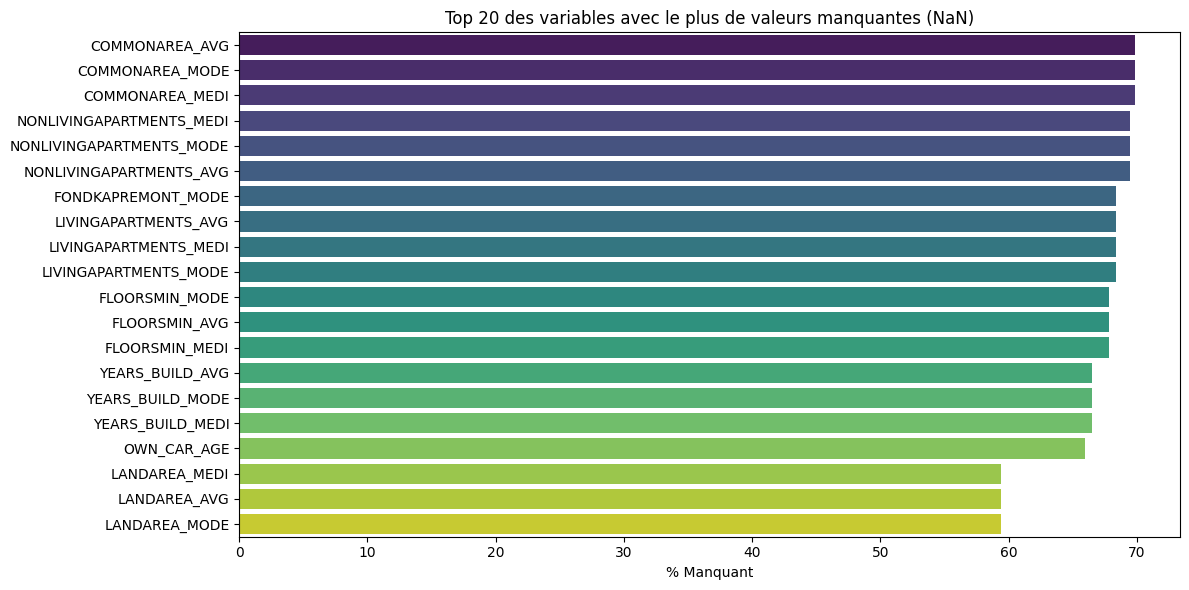

--- application_test : Valeurs manquantes max = 68.72% ---
--- bureau : Valeurs manquantes max = 71.47% ---
--- previous_application : Valeurs manquantes max = 99.64% ---
--- installments_payments : Valeurs manquantes max = 0.02% ---
--- credit_card_balance : Valeurs manquantes max = 20.00% ---
--- POS_CASH_balance : Valeurs manquantes max = 0.26% ---


In [7]:
for name, df in datasets.items():
    missing = df.isna().mean().mul(100).sort_values(ascending=False).reset_index()
    missing.columns = ["colonne", "pct_manquant"]
    missing["nb_manquant"] = df.isna().sum().values
    
    if name == "application_train":
        print("=" * 100)
        print(f"Visualisation des valeurs manquantes - {name}")
        
        plt.figure(figsize=(12, 6))
        sns.barplot(data=missing.head(20), x="pct_manquant", y="colonne", palette="viridis")
        plt.title("Top 20 des variables avec le plus de valeurs manquantes (NaN)")
        plt.xlabel("% Manquant")
        plt.ylabel("")
        plt.tight_layout()
        plt.show()
    else:
        if missing['pct_manquant'].max() > 0:
            print(f"--- {name} : Valeurs manquantes max = {missing['pct_manquant'].max():.2f}% ---")

## 8. Valeurs aberrantes (outliers)

L’analyse des valeurs aberrantes est basée sur la méthode statistique de l'écart interquartile (IQR). Plutôt que de supprimer aveuglément ces valeurs, nous les visualisons pour confirmer qu'elles reflètent une réalité métier (ex: des revenus ou des crédits exceptionnellement élevés mais légitimes).

,colonne,nb_outliers,borne_min,borne_max
0,AMT_INCOME_TOTAL,14035,"-22,500.0000","337,500.0000"
1,AMT_CREDIT,6562,"-537,975.0000","1,616,625.0000"
2,AMT_ANNUITY,7504,"-10,584.0000","61,704.0000"


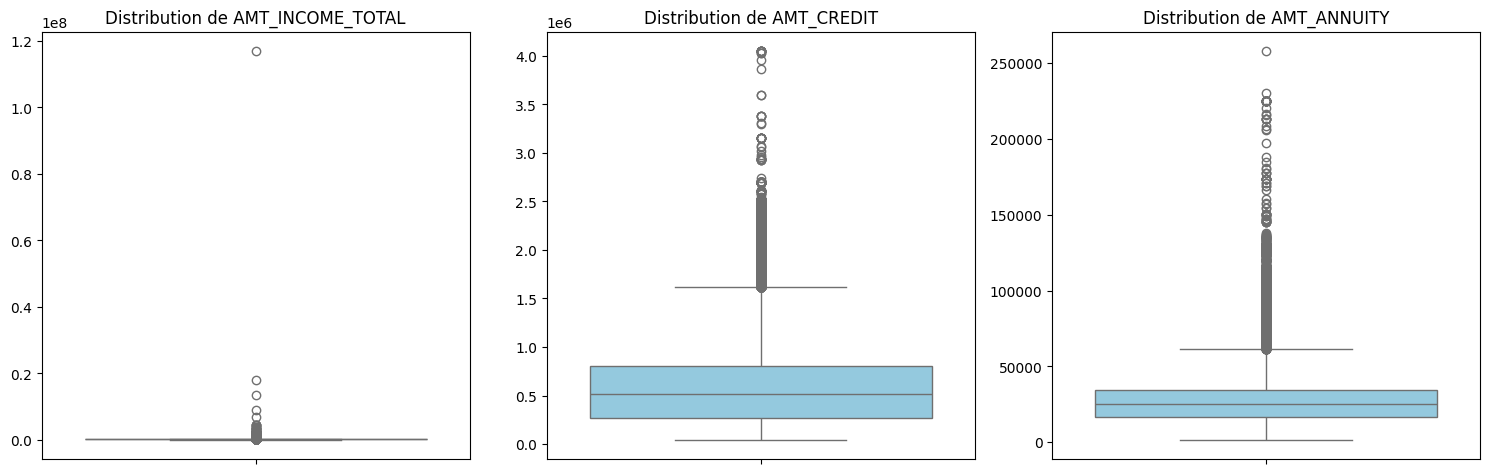

In [8]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

columns_to_check = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"]
outliers_summary = []
app_train = datasets["application_train"]

for col in columns_to_check:
    n_outliers, low, high = detect_outliers_iqr(app_train, col)
    outliers_summary.append({"colonne": col, "nb_outliers": n_outliers, "borne_min": low, "borne_max": high})

display(pd.DataFrame(outliers_summary))

# Visualisation des distributions
plt.figure(figsize=(15, 5))
for i, col in enumerate(columns_to_check, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=app_train[col], color="skyblue")
    plt.title(f"Distribution de {col}")
    plt.ylabel("")

plt.tight_layout()
plt.show()

## 9. Doublons et identifiants

In [9]:
duplicate_checks = []

for name, df in datasets.items():
    row_duplicates = int(df.duplicated().sum())
    pk = primary_keys.get(name)

    if pk is not None and pk in df.columns:
        pk_duplicates = int(df[pk].duplicated().sum())
    else:
        pk_duplicates = "N/A"

    duplicate_checks.append({
        "dataset": name,
        "doublons_lignes": row_duplicates,
        "id_principal": pk if pk is not None else "Non défini",
        "doublons_id_principal": pk_duplicates,
    })

pd.DataFrame(duplicate_checks)

,dataset,doublons_lignes,id_principal,doublons_id_principal
0,application_train,0,SK_ID_CURR,0
1,application_test,0,SK_ID_CURR,0
2,bureau,0,SK_ID_BUREAU,0
3,bureau_balance,0,Non défini,N/A
4,previous_application,0,SK_ID_PREV,0
5,installments_payments,0,Non défini,N/A
6,credit_card_balance,0,Non défini,N/A
7,POS_CASH_balance,0,Non défini,N/A


### Remarque
L'unicité de l'identifiant dépend du niveau de granularité de la table.
Aucun doublon exact de lignes n’a été détecté dans les datasets. Certaines tables contiennent plusieurs enregistrements pour un même identifiant, ce qui est normal car elles représentent des données transactionnelles ou historiques.

## 10. Analyse ciblée de la variable cible

In [10]:
target_distribution = (
    datasets["application_train"]["TARGET"]
    .value_counts(dropna=False)
    .rename_axis("TARGET")
    .reset_index(name="count")
)

target_distribution["pct"] = target_distribution["count"] / target_distribution["count"].sum() * 100
target_distribution

,TARGET,count,pct
0,0,282686,91.9271
1,1,24825,8.0729


### Interprétation
Le dataset principal `application_train` contient une variable cible fortement déséquilibrée (~92% vs ~8%). Cette caractéristique devra être prise en compte dans la phase de modélisation (ex: SMOTE, poids des classes) et dans l'analyse des métriques (privilégier le F1-Score et Recall plutôt que l'Accuracy).

## 11. Vérifications métier par dataset

In [11]:
business_rules_summary = []

app_train = datasets["application_train"]
business_rules_summary.append({
    "dataset": "application_train",
    "règle": "AMT_INCOME_TOTAL >= 0",
    "nb_violations": int((app_train["AMT_INCOME_TOTAL"] < 0).sum())
})
business_rules_summary.append({
    "dataset": "application_train",
    "règle": "DAYS_BIRTH < 0",
    "nb_violations": int((app_train["DAYS_BIRTH"] >= 0).sum())
})

bureau = datasets["bureau"]
if "AMT_CREDIT_SUM" in bureau.columns:
    business_rules_summary.append({
        "dataset": "bureau",
        "règle": "AMT_CREDIT_SUM >= 0 ou NaN",
        "nb_violations": int(((bureau["AMT_CREDIT_SUM"] < 0) & bureau["AMT_CREDIT_SUM"].notna()).sum())
    })

prev = datasets["previous_application"]
if "AMT_APPLICATION" in prev.columns:
    business_rules_summary.append({
        "dataset": "previous_application",
        "règle": "AMT_APPLICATION >= 0 ou NaN",
        "nb_violations": int(((prev["AMT_APPLICATION"] < 0) & prev["AMT_APPLICATION"].notna()).sum())
    })

inst = datasets["installments_payments"]
if "AMT_PAYMENT" in inst.columns:
    business_rules_summary.append({
        "dataset": "installments_payments",
        "règle": "AMT_PAYMENT >= 0 ou NaN",
        "nb_violations": int(((inst["AMT_PAYMENT"] < 0) & inst["AMT_PAYMENT"].notna()).sum())
    })

ccb = datasets["credit_card_balance"]
if "AMT_BALANCE" in ccb.columns:
    business_rules_summary.append({
        "dataset": "credit_card_balance",
        "règle": "AMT_BALANCE peut être négatif, nul ou positif",
        "nb_violations": "Non applicable"
    })

pos = datasets["POS_CASH_balance"]
if "CNT_INSTALMENT" in pos.columns:
    business_rules_summary.append({
        "dataset": "POS_CASH_balance",
        "règle": "CNT_INSTALMENT >= 0 ou NaN",
        "nb_violations": int(((pos["CNT_INSTALMENT"] < 0) & pos["CNT_INSTALMENT"].notna()).sum())
    })

pd.DataFrame(business_rules_summary)

,dataset,règle,nb_violations
0,application_train,AMT_INCOME_TOTAL >= 0,0
1,application_train,DAYS_BIRTH < 0,0
2,bureau,AMT_CREDIT_SUM >= 0 ou NaN,0
3,previous_application,AMT_APPLICATION >= 0 ou NaN,0
4,installments_payments,AMT_PAYMENT >= 0 ou NaN,0
5,credit_card_balance,"AMT_BALANCE peut être négatif, nul ou positif",Non applicable
6,POS_CASH_balance,CNT_INSTALMENT >= 0 ou NaN,0


## 12. Validation des schémas (Pandera & YAML)

Après l’analyse exploratoire et visuelle, les règles métier identifiées sont automatisées.
L'utilisation combinée d'un fichier de configuration YAML (pour la lisibilité) et de Pandera (pour l'exécution) permet de :
- Vérifier strictement les types de données.
- Valider les contraintes métier (ex: revenus positifs).
- Sécuriser le pipeline avant d'entamer le feature engineering.

In [12]:
import sys
import yaml

sys.path.append(str(PROJECT_ROOT))

# 1. Aperçu de la configuration YAML
with open(PROJECT_ROOT / "configs" / "application_quality.yaml", "r") as f:
    yaml_config = yaml.safe_load(f)

print("Aperçu des règles définies dans le YAML pour application_train :")
display(yaml_config['datasets']['application_train'])

# 2. Exécution des validations Pandera
from configs.pandera_schemas import (
    validate_application_train,
    validate_bureau,
    validate_previous_application,
    validate_installments_payments,
    validate_credit_card_balance,
    validate_pos_cash_balance,
    validate_bureau_balance
)

print("\nRésultats de la validation Pandera (Dimensions post-validation) :")
print("- application_train :", validate_application_train(datasets["application_train"]).shape)
print("- bureau :", validate_bureau(datasets["bureau"]).shape)
print("- previous_application :", validate_previous_application(datasets["previous_application"]).shape)
print("- installments :", validate_installments_payments(datasets["installments_payments"]).shape)
print("- credit_card :", validate_credit_card_balance(datasets["credit_card_balance"]).shape)
print("- POS_CASH :", validate_pos_cash_balance(datasets["POS_CASH_balance"]).shape)
print("- bureau_balance :", validate_bureau_balance(datasets["bureau_balance"]).shape)

Aperçu des règles définies dans le YAML pour application_train :


{'columns': {'SK_ID_CURR': {'type': 'integer',
   'nullable': False,
   'unique': True},
  'TARGET': {'type': 'integer', 'nullable': False, 'allowed_values': [0, 1]},
  'AMT_INCOME_TOTAL': {'type': 'float', 'nullable': False, 'min': 0},
  'DAYS_BIRTH': {'type': 'integer', 'nullable': False, 'max': 0}}}


Résultats de la validation Pandera (Dimensions post-validation) :
- application_train : (307511, 122)
- bureau : (1716428, 17)
- previous_application : (1670214, 37)
- installments : (13605401, 8)
- credit_card : (3840312, 23)
- POS_CASH : (10001358, 8)
- bureau_balance : (27299925, 3)


## Phase 2 : Validation de l'Ingénierie des Caractéristiques

Le contrôle qualité s'applique également lors de la transformation des données. Avant d'injecter de nouvelles variables explicatives dans le modèle, nous devons nous assurer de deux choses :
1. **Tests Unitaires :** Nos fonctions de calcul produisent les résultats mathématiques attendus sur des données de test fictives.
2. **Data Leakage (Fuite de données) :** Aucune variable explicative ne contient d'information "du futur" (une corrélation suspectement élevée avec la variable cible `TARGET`).

In [16]:
# ==========================================
# 1. Fonction d'Ingénierie des Caractéristiques
# ==========================================
def create_financial_features(df):
    """
    Crée des variables métiers (Feature Engineering) basées sur 
    les règles d'octroi de crédit pour les particuliers.
    """
    df_out = df.copy()
    
    # Éviter les divisions par zéro
    df_out['AMT_INCOME_TOTAL'] = df_out['AMT_INCOME_TOTAL'].replace(0, np.nan)
    df_out['AMT_GOODS_PRICE'] = df_out['AMT_GOODS_PRICE'].replace(0, np.nan)
    df_out['DAYS_BIRTH'] = df_out['DAYS_BIRTH'].replace(0, np.nan)
    
    # 1. Taux d'endettement (Poids de la mensualité sur le salaire)
    df_out['ANNUITY_INCOME_RATIO'] = df_out['AMT_ANNUITY'] / df_out['AMT_INCOME_TOTAL']
    
    # 2. Reste à vivre (Ce qu'il reste après avoir payé la mensualité)
    df_out['RESTE_A_VIVRE'] = df_out['AMT_INCOME_TOTAL'] - df_out['AMT_ANNUITY']
    
    # 3. Apport personnel (Si le crédit demandé est inférieur au prix du bien)
    df_out['CREDIT_TO_GOODS_RATIO'] = df_out['AMT_CREDIT'] / df_out['AMT_GOODS_PRICE']
    
    # 4. Stabilité professionnelle (Pourcentage de la vie passée à travailler)
    # Les jours sont négatifs, la division donne un pourcentage positif
    df_out['EMPLOYED_TO_AGE_RATIO'] = df_out['DAYS_EMPLOYED'] / df_out['DAYS_BIRTH']
    
    # 5. Synthèse des scores externes (Moyenne des 3 scores de crédit)
    df_out['EXT_SOURCES_MEAN'] = df_out[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
    
    return df_out

# ==========================================
# 2. Test Unitaire du Pipeline (Mock Data)
# ==========================================
def test_create_financial_features():
    """
    Vérifie que les calculs financiers sont mathématiquement exacts
    sur un jeu de données fictif.
    """
    # Création d'un client fictif pour tester la logique
    mock_data = pd.DataFrame({
        'AMT_INCOME_TOTAL': [100000],  # Gagne 100k
        'AMT_ANNUITY': [30000],        # Paie 30k de crédit
        'AMT_CREDIT': [150000],        # Emprunte 150k
        'AMT_GOODS_PRICE': [200000],   # Achète un bien à 200k (donc 50k d'apport)
        'DAYS_EMPLOYED': [-3650],      # Travaille depuis 10 ans
        'DAYS_BIRTH': [-14600],        # A 40 ans
        'EXT_SOURCE_1': [0.5],
        'EXT_SOURCE_2': [0.6],
        'EXT_SOURCE_3': [0.7]
    })
    
    # Application de la fonction
    res = create_financial_features(mock_data)
    
    # np.isclose vérifie l'égalité des floats de manière sécurisée
    assert np.isclose(res.loc[0, 'ANNUITY_INCOME_RATIO'], 0.30), "Erreur Ratio Endettement"
    assert res.loc[0, 'RESTE_A_VIVRE'] == 70000, "Erreur Reste à Vivre" # Reste à vivre est un entier strict, le == est ok
    assert np.isclose(res.loc[0, 'CREDIT_TO_GOODS_RATIO'], 0.75), "Erreur Apport Personnel"
    assert np.isclose(res.loc[0, 'EMPLOYED_TO_AGE_RATIO'], 0.25), "Erreur Stabilité Pro"
    assert np.isclose(res.loc[0, 'EXT_SOURCES_MEAN'], 0.60), "Erreur Moyenne Scores"
    
    print("✅ Succès : Tous les tests unitaires d'ingénierie des caractéristiques sont validés !\n")

# On lance le test
test_create_financial_features()

# ==========================================
# 3. Application sur les vraies données
# ==========================================
print("Création des nouvelles variables sur le dataset d'entraînement...")
app_train_featured = create_financial_features(datasets["application_train"])
print(f"Nouvelles dimensions : {app_train_featured.shape}")

✅ Succès : Tous les tests unitaires d'ingénierie des caractéristiques sont validés !

Création des nouvelles variables sur le dataset d'entraînement...
Nouvelles dimensions : (307511, 127)


### Vérification de la Fuite de Données (Data Leakage)

Pour s'assurer qu'aucune information du futur n'est présente, nous scannons les corrélations absolues de toutes les variables avec la `TARGET`. Une valeur trop proche de 1 est très suspecte.

In [18]:
def check_data_leakage(df, target_col='TARGET', threshold=0.8):
    """
    Identifie les variables ayant une corrélation suspecte avec la cible.
    """
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    numeric_df = df.select_dtypes(include=numerics)
    
    correlations = numeric_df.corrwith(df[target_col]).abs().sort_values(ascending=False)
    correlations = correlations.drop(target_col, errors='ignore')
    
    leaks = correlations[correlations > threshold]
    
    if len(leaks) > 0:
        print(f" ALERTE DATA LEAKAGE : {len(leaks)} variables suspectes trouvées au-dessus du seuil de {threshold} !")
        display(leaks)
    else:
        print(f"Aucune corrélation suspecte supérieure à {threshold} n’a été détectée.")
        print("Cela ne prouve pas l’absence totale de fuite de données, mais ne met pas en évidence d’alerte immédiate.")
        display(correlations.head(5))

check_data_leakage(app_train_featured)

Aucune corrélation suspecte supérieure à 0.8 n’a été détectée.
Cela ne prouve pas l’absence totale de fuite de données, mais ne met pas en évidence d’alerte immédiate.


EXT_SOURCES_MEAN   0.2221
EXT_SOURCE_3       0.1789
EXT_SOURCE_2       0.1605
EXT_SOURCE_1       0.1553
DAYS_BIRTH         0.0782
dtype: float64

## Conclusion et Prochaines étapes

Le Contrôle Qualité (Data QC) et la création de variables financières sont désormais validés via des tests stricts et une vérification de fuite de données.

**Prochaine étape : Phase 3 - Validation du Modèle**
Nous allons maintenant pouvoir entraîner notre modèle, configurer la validation croisée stratifiée et analyser les métriques de confusion en intégrant les coûts métiers.